# ElasticNet Regression

This notebook implements ElasticNet regression for car price estimation, tuning both penalty strength (alpha) and the L1 ratio to combine the feature selection of Lasso with the grouping stability of Ridge.

## 1. Imports

In [12]:
# suppress warnings to keep notebook clean
import warnings
warnings.filterwarnings("ignore")

# data handling and plotting
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn elasticnet, preprocessing, and metrics
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
)

# random seed and visual theme
RANDOM_STATE = 42
sns.set_theme(style="whitegrid")

## 2. Dataset audit and preprocessing

In [ ]:
# dataset source and target variable
DATA_URL = "https://raw.githubusercontent.com/rohithtej2109/Smart-car-deals/b438f32fc37ae91e6f8a72ef912705b2c48b427f/cardekho_dataset.csv"
TARGET = "selling_price"

df = pd.read_csv(DATA_URL)
df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]

# convert target to numeric and drop duplicate records
df[TARGET] = pd.to_numeric(df[TARGET], errors="coerce")
df = df.drop_duplicates().dropna(subset=[TARGET]).copy()

# split features and target
X = df.drop(columns=[TARGET])
y = df[TARGET]

# 80-20 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

# group numeric and categorical features
numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=np.number).columns.tolist()

# construct column preprocessing pipeline
preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), numeric_features),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ]), categorical_features)
])

# print summary info
print("Shape:", df.shape)
print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Shape: (15411, 14)
Numeric features: ['unnamed:_0', 'vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats']
Categorical features: ['car_name', 'brand', 'model', 'seller_type', 'fuel_type', 'transmission_type']


## 3. Required EDA

,unnamed:_0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
unnamed:_0,15411.0,NaN,NaN,NaN,9811.857699,5643.418542,0.0,4906.5,9872.0,14668.5,19543.0
car_name,15411,121,Hyundai i20,906,NaN,NaN,NaN,NaN,NaN,NaN,NaN
brand,15411,32,Maruti,4992,NaN,NaN,NaN,NaN,NaN,NaN,NaN
model,15411,120,i20,906,NaN,NaN,NaN,NaN,NaN,NaN,NaN
vehicle_age,15411.0,NaN,NaN,NaN,6.036338,3.013291,0.0,4.0,6.0,8.0,29.0
km_driven,15411.0,NaN,NaN,NaN,55616.480631,51618.548422,100.0,30000.0,50000.0,70000.0,3800000.0
seller_type,15411,3,Dealer,9539,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fuel_type,15411,5,Petrol,7643,NaN,NaN,NaN,NaN,NaN,NaN,NaN
transmission_type,15411,2,Manual,12225,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mileage,15411.0,NaN,NaN,NaN,19.701151,4.171265,4.0,17.0,19.67,22.7,33.54


Missing values:
 unnamed:_0           0
car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64


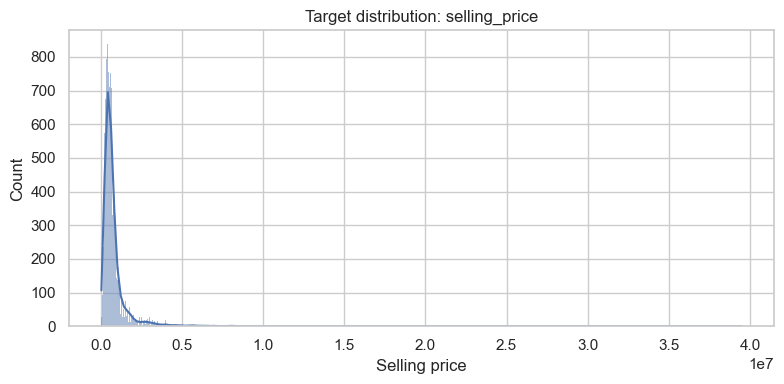

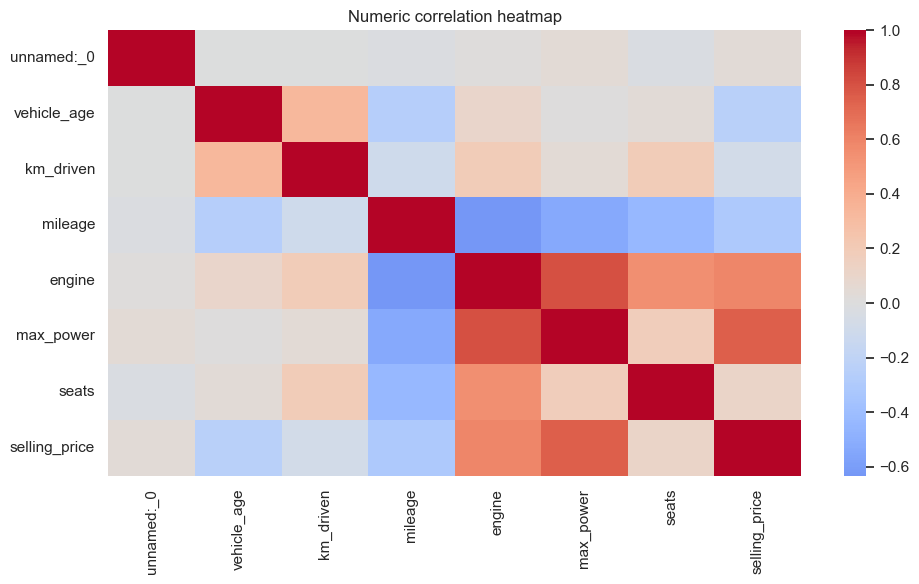

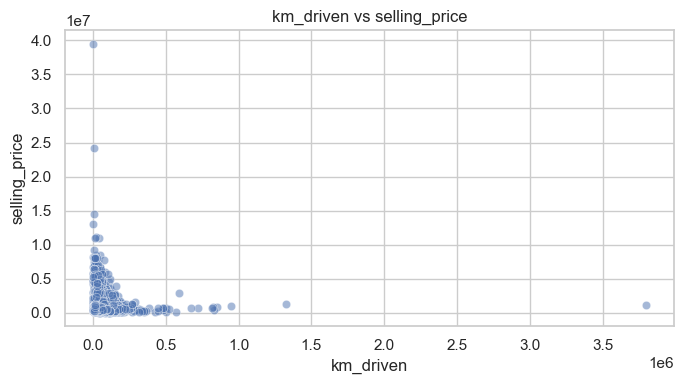

In [7]:
# inspect dataset and check for missing values
display(df.head())
display(df.describe(include="all").T)
print("Missing values:\n", df.isna().sum())

# plot target selling price distribution
plt.figure(figsize=(8,4)); sns.histplot(y, kde=True); plt.title("Target distribution: selling_price"); plt.xlabel("Selling price"); plt.tight_layout(); plt.show()

# heatmap of numeric correlations
plt.figure(figsize=(10,6)); sns.heatmap(df.select_dtypes(include=np.number).corr(), cmap="coolwarm", center=0); plt.title("Numeric correlation heatmap"); plt.tight_layout(); plt.show()

# scatter plots of key numeric features vs price
for col in [c for c in ["year","km_driven","car_age"] if c in df.columns]:
    plt.figure(figsize=(7,4)); sns.scatterplot(data=df, x=col, y=TARGET, alpha=.5); plt.title(f"{col} vs selling_price"); plt.tight_layout(); plt.show()

## 4. Model training and optional tuning

In [8]:
# initialize elasticnet regressor inside pipeline
base_model = ElasticNet(max_iter=30000)
model = Pipeline([("preprocessor", preprocessor), ("model", base_model)])

In [16]:
# tune alpha and l1_ratio using 5-fold cross-validated grid search
param_grid = {"model__alpha": [0.01, 0.1, 1],"model__l1_ratio": [0.2, 0.5, 0.8]}
search = GridSearchCV(model,param_grid,cv=5,scoring="r2",n_jobs=-1)
search.fit(X_train, y_train)

# retrieve best parameters and estimator
model = search.best_estimator_
print("Best parameters:", search.best_params_)
print("Best CV R2:", search.best_score_)

Best parameters: {'model__alpha': 0.01, 'model__l1_ratio': 0.8}
Best CV R2: 0.6842649657263746


## 5. Evaluation

In [13]:
# generate predictions on test split
pred = model.predict(X_test)

# compute test metrics
results = pd.DataFrame([{
    "Model": 'ElasticNet Regression',
    "R2": r2_score(y_test, pred),
    "RMSE": root_mean_squared_error(y_test, pred),
    "MAE": mean_absolute_error(y_test, pred)
}])
display(results)

# 5-fold cross validation score
cv_r2 = cross_val_score(model, X, y, cv=5, scoring="r2", n_jobs=-1)
print("5-fold CV R2 mean:", cv_r2.mean())
print("5-fold CV R2 std:", cv_r2.std())

,Model,R2,RMSE,MAE
0,ElasticNet Regression,0.758597,426290.648962,214346.881505


5-fold CV R2 mean: 0.7092897209217262
5-fold CV R2 std: 0.07549375041162074


## 6. Required visualisations / interpretation

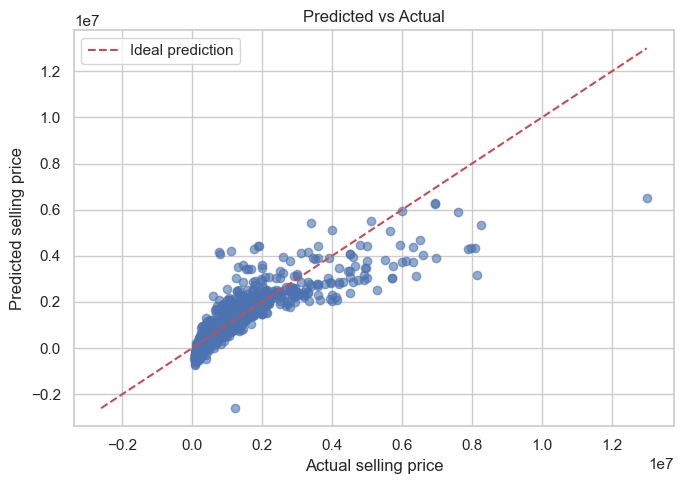

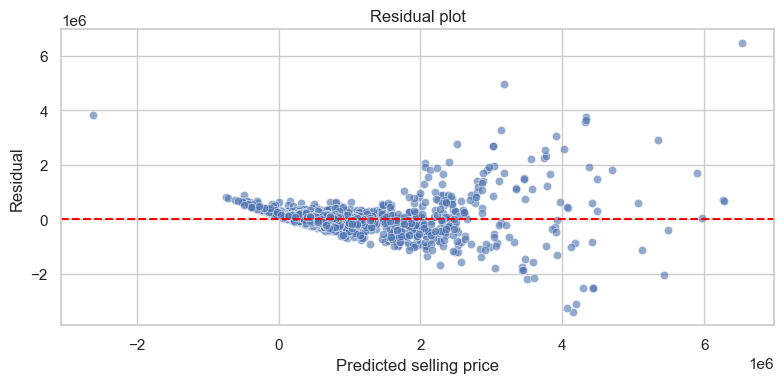

In [14]:
# plot actual vs predicted values
fig, ax = plt.subplots(figsize=(7,5))
ax.scatter(y_test, pred, alpha=.6)
lims=[min(y_test.min(), pred.min()), max(y_test.max(), pred.max())]
ax.plot(lims, lims, "r--", label="Ideal prediction")
ax.set_xlabel("Actual selling price"); ax.set_ylabel("Predicted selling price")
ax.set_title("Predicted vs Actual"); ax.legend(); plt.tight_layout(); plt.show()

# plot residuals to inspect prediction errors
residuals = y_test - pred
plt.figure(figsize=(8,4)); sns.scatterplot(x=pred, y=residuals, alpha=.6)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted selling price"); plt.ylabel("Residual")
plt.title("Residual plot"); plt.tight_layout(); plt.show()

# check for feature importances if available
if hasattr(model.named_steps["model"], "feature_importances_"):
    names = model.named_steps["preprocessor"].get_feature_names_out()
    imp = pd.Series(model.named_steps["model"].feature_importances_, index=names).sort_values(ascending=False).head(15)
    plt.figure(figsize=(8,5)); imp.sort_values().plot(kind="barh")
    plt.title("Top feature importances"); plt.xlabel("Importance"); plt.tight_layout(); plt.show()

### Interpretation & Observations

- **Hyperparameter Balance:** Grid search identified **$\alpha = 0.01$** and **`l1_ratio` = 0.8** as the optimal configuration. The 0.8 L1 ratio indicates that the dataset responds best to predominantly L1 (sparse) penalty with a 20% L2 component to stabilize correlated feature groups.
- **Superior Cross-Validation Stability:** The 5-fold CV mean score is **0.7093** with a standard deviation of **$\pm 0.0755$**. This standard deviation is the lowest among all linear models (compared to $\pm 0.104$ for OLS and $\pm 0.112$ for Lasso), showing that ElasticNet is the least sensitive to variations across folds.
- **Test Metric Trade-off:** The test $R^2$ is **0.7586 (~75.9%)** with an MAE of **₹214,347** and RMSE of **₹426,291**. The slight drop compared to unregularized OLS reflects the shrinkage penalty pulling coefficients inward to prevent overfitting, trading marginal test accuracy for lower variance.
- **Residual Distribution:** Residual plots show consistent centered errors for mid-range vehicles, with reduced sensitivity to extreme outliers compared to purely unregularized models.